In [9]:
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour,
    plot_slice,
    plot_edf,
)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import seaborn as sns
sns.set_theme(style="whitegrid")


In [10]:
study = optuna.load_study(
    study_name = "cadgn_stage1_search",
    storage= "sqlite:///search.db",
)




In [11]:
## 1 Optimization History
def plot_optimization_history(
    study: optuna.Study,
    figsize: tuple[int, int] = (12, 5),
    objective_name: str = "Objective",
    save_path: str | None = None,
) -> None:
    """
    Plots optimization history for an Optuna study using seaborn/matplotlib.
    Shows:
      - Per-trial objective value (scatter)
      - Running best value (line)
      - Pruned trials marked distinctly
    """
    df = study.trials_dataframe()

    # Separate completed and pruned trials
    completed = df[df["state"] == "COMPLETE"].copy()
    pruned    = df[df["state"] == "PRUNED"].copy()

    # Compute running best across completed trials (in trial order)
    direction = study.direction
    is_minimize = direction == optuna.study.StudyDirection.MINIMIZE

    completed = completed.sort_values("number").reset_index(drop=True)
    if is_minimize:
        completed["running_best"] = completed["value"].cummin()
    else:
        completed["running_best"] = completed["value"].cummax()

    # Figure
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(style="whitegrid", font_scale=1.1)

    # Completed trials — scatter
    sns.scatterplot(
        data=completed,
        x="number",
        y="value",
        ax=ax,
        color="steelblue",
        alpha=0.5,
        s=30,
        label="Trial value",
        zorder=2,
    )

    # Pruned trials are marked separately
    if not pruned.empty:
        # Pruned trials have NaN values; plot at a visible baseline
        pruned_y = pruned["value"].fillna(
            completed["value"].max() if not completed.empty else 0
        )
        ax.scatter(
            pruned["number"],
            pruned_y,
            marker="x",
            color="tomato",
            alpha=0.6,
            s=40,
            label="Pruned trial",
            zorder=2,
        )

    # Running best as a line
    ax.plot(
        completed["number"],
        completed["running_best"],
        color="darkorange",
        linewidth=2.0,
        label=f"Running {'min' if is_minimize else 'max'}",
        zorder=3,
    )

    # Best trial annotation
    if not completed.empty:
        best = study.best_trial
        ax.axvline(
            x=best.number,
            color="darkorange",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
        )
        ax.annotate(
            f"Best: {best.value:.4f}\n(trial {best.number})",
            xy=(best.number, best.value),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=9,
            color="darkorange",
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.0),
        )

    # Formatting
    ax.set_xlabel("Trial Number", fontsize=11)
    ax.set_ylabel(objective_name, fontsize=11)
    ax.set_title("Optuna Optimisation History", fontsize=13, fontweight="bold")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(framealpha=0.9, fontsize=10)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

Saved to optuna_history.pdf


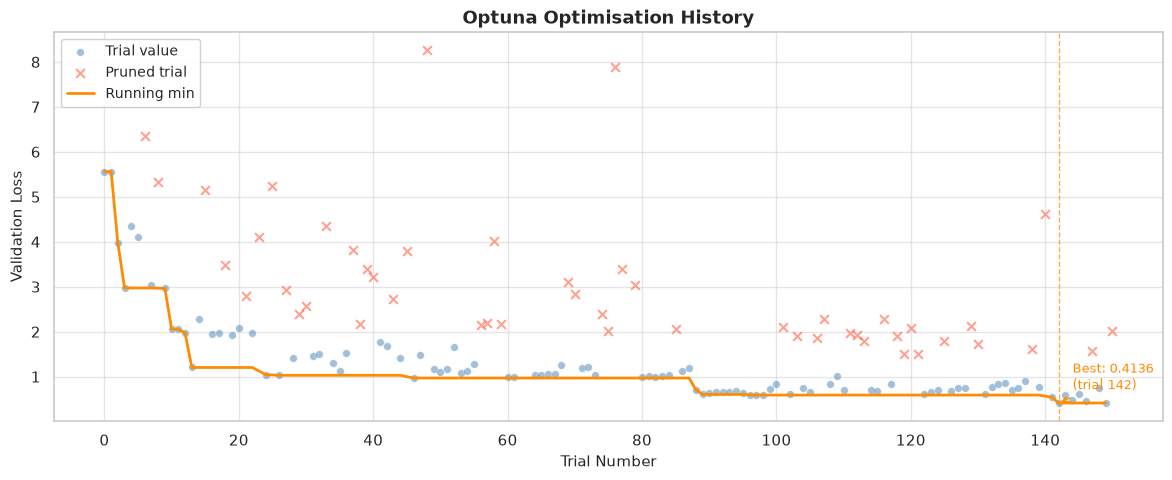

In [12]:
plot_optimization_history(
    study,
    objective_name="Validation Loss",
    save_path="optuna_history.pdf",  # vector PDF for paper
)

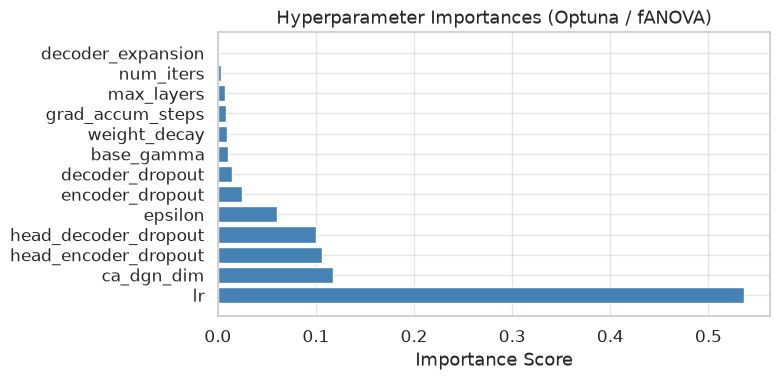

In [13]:
## Get Feature Importances
df = study.trials_dataframe()
# columns: number, value, params_*, datetime_start, duration, state

# Example: parameter importance as a static bar chart
importances = optuna.importance.get_param_importances(study)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(
    list(importances.keys()),
    list(importances.values()),
    color="steelblue"
)
ax.set_xlabel("Importance Score")
ax.set_title("Hyperparameter Importances (Optuna / fANOVA)")
plt.tight_layout()


In [18]:
## Plot Parallel Coordinates
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

def plot_parallel_coordinates(
    study: optuna.Study,
    params: list[str] | None = None,
    figsize: tuple[int, int] = (14, 6),
    n_best_highlight: int = 10,
    objective_name: str = "Objective",
    save_path: str | None = None,
) -> None:
    """
    Parallel coordinates plot for an Optuna study.
    Each line = one trial. Lines are coloured by objective value.
    The n_best trials are drawn on top with higher opacity.
    :param study: Optuna study object
    :param params: list of parameter names to include. None = all.
    :param figsize: figure size
    :param n_best_highlight: top-N trials drawn with full opacity on top layer
    :param objective_name: label for the colour bar
    :param save_path: if provided, saves to this path
    """
    df = study.trials_dataframe()
    df = df[df["state"] == "COMPLETE"].copy()

    # Select parameter columns
    param_cols = [c for c in df.columns if c.startswith("params_")]
    if params is not None:
        param_cols = [f"params_{p}" for p in params if f"params_{p}" in df.columns]

    if not param_cols:
        raise ValueError("No parameter columns found in study trials dataframe.")

    # Clean display names (strip "params_" prefix)
    display_names = [c.replace("params_", "") for c in param_cols]

    # Normalise each parameter axis to [0, 1] for plotting
    normed = pd.DataFrame()
    for col in param_cols:
        col_min = df[col].min()
        col_max = df[col].max()
        if col_max == col_min:
            normed[col] = 0.5
        else:
            normed[col] = (df[col] - col_min) / (col_max - col_min)

    # Colour map over objective value
    is_minimize = (
        study.direction == optuna.study.StudyDirection.MINIMIZE
    )
    obj_vals    = df["value"].values
    obj_norm    = mcolors.Normalize(
        vmin=obj_vals.min(), vmax=obj_vals.max()
    )
    # Invert colourmap for minimization so best = brightest
    cmap = cmap = plt.colormaps["viridis_r" if is_minimize else "viridis"]

    # Sort: worst trials drawn first, best on top
    sort_ascending = not is_minimize
    # ascending = worst first for minimize
    normed = normed.loc[df.index]

    # Now reset both together
    df     = df.reset_index(drop=True)
    normed = normed.reset_index(drop=True)

    obj_vals = df["value"].values

    n_params = len(param_cols)
    x_positions = np.arange(n_params)

    # Build line segments
    segments_bg   = []
    colours_bg    = []
    segments_top  = []
    colours_top   = []

    best_indices = set(range(len(df) - n_best_highlight, len(df)))

    for i, row in normed.iterrows():
        y_vals   = row[param_cols].values.astype(float)
        pts      = np.column_stack([x_positions, y_vals])
        segs     = [[pts[j], pts[j + 1]] for j in range(len(pts) - 1)]
        colour   = cmap(obj_norm(obj_vals[i]))

        if i in best_indices:
            segments_top.extend(segs)
            colours_top.extend([colour] * len(segs))
        else:
            segments_bg.extend(segs)
            colours_bg.extend([colour] * len(segs))

    # Plot
    sns.set_theme(style="whitegrid", font_scale=1.1)
    fig, ax = plt.subplots(figsize=figsize)

    # Background trials = low alpha
    if segments_bg:
        lc_bg = LineCollection(
            segments_bg, colors=colours_bg, linewidth=0.6, alpha=0.25
        )
        ax.add_collection(lc_bg)

    # Top N trials = full opacity
    if segments_top:
        lc_top = LineCollection(
            segments_top, colors=colours_top, linewidth=1.5, alpha=0.9
        )
        ax.add_collection(lc_top)

    # Axes and tick labels
    ax.set_xlim(-0.1, n_params - 0.9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(display_names, fontsize=10, rotation=15, ha="right")
    ax.set_yticks([])   # y-axis is normalised ; not meaningful globally

    # Per-axis tick annotations (min/max original values)
    for i, col in enumerate(param_cols):
        col_min = df[col].min()
        col_max = df[col].max()
        ax.text(
            i, -0.03, f"{col_min:.3g}",
            ha="center", va="top", fontsize=8, color="grey"
        )
        ax.text(
            i, 1.03, f"{col_max:.3g}",
            ha="center", va="bottom", fontsize=8, color="grey"
        )
        # Vertical axis line
        ax.axvline(x=i, color="black", linewidth=0.8, alpha=0.4)

    # Colourbar
    sm = cm.ScalarMappable(cmap=cmap, norm=obj_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.02)
    cbar.set_label(
        f"{objective_name} ({'min' if is_minimize else 'max'}↑)",
        fontsize=10
    )

    ax.set_title(
        f"Parallel Coordinates : Hyperparameter Space\n"
        f"({len(df)} completed trials, top {n_best_highlight} highlighted)",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

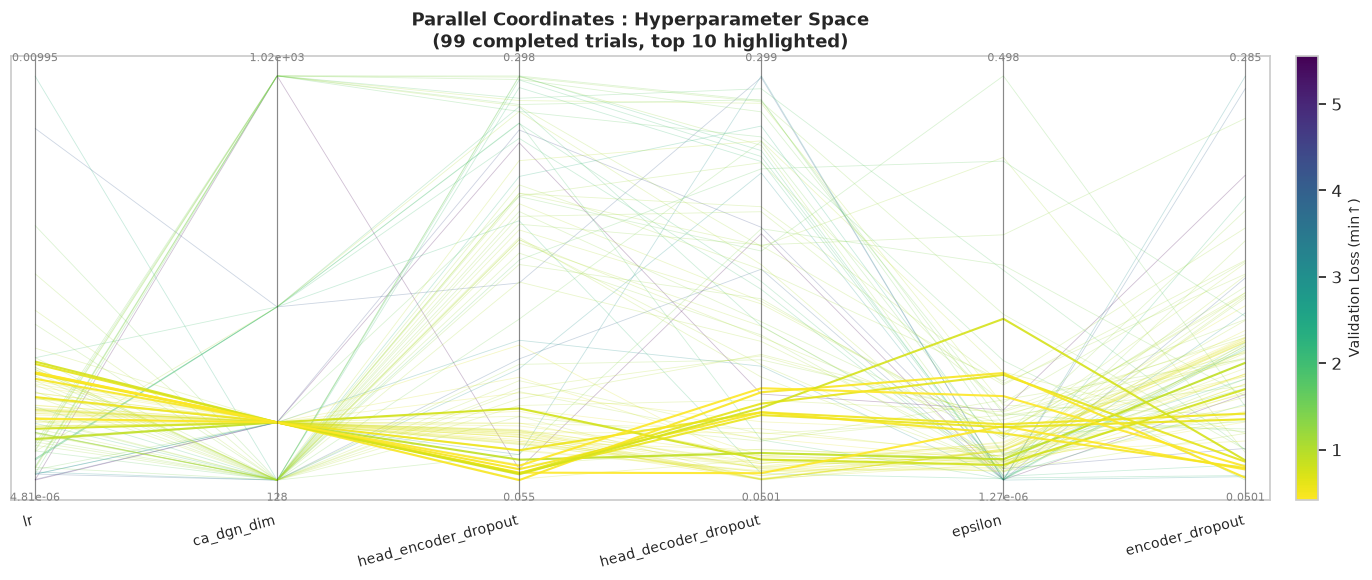

In [19]:
plot_parallel_coordinates(
    study,
    params=["lr", "ca_dgn_dim", "head_encoder_dropout",
            "head_decoder_dropout",
            "epsilon", "encoder_dropout"
            ],  # or None for all
    objective_name="Validation Loss",
    n_best_highlight=10,
    #save_path="parallel_coords.pdf",
)

In [20]:
## Contour Surface for Important Features
# RBFInterpolant
from scipy.interpolate import RBFInterpolator, LinearNDInterpolator

from scipy.stats import gaussian_kde

def plot_loss_contour(
    study: optuna.Study,
    param_x: str,
    param_y: str,
    objective_name: str = "Objective",
    resolution: int = 80,
    interpolation: str = "rbf",   # "rbf" | "linear"
    log_x: bool = False,          # set True if param is log-scaled (e.g. lr)
    log_y: bool = False,
    figsize: tuple[int, int] = (9, 7),
    save_path: str | None = None,
) -> None:
    """
    Plots a 2D loss surface contour over two Optuna hyperparameters,
    interpolated from sampled trial points.
    :param study: Optuna study
    :param param_x: name of the x-axis parameter (e.g. "lr")
    :param param_y: name of the y-axis parameter (e.g. "ca_dgn_dim")
    :param objective_name: label for the colour bar
    :param resolution: grid resolution (higher = smoother, slower)
    :param interpolation: "rbf" (smoother, better for sparse) or "linear" (faster)
    :param log_x: if True, x-axis and interpolation are in log10 space
    :param log_y: if True, y-axis and interpolation are in log10 space
    :param save_path: if provided, saves to this path at 300 dpi
    """
    # Extract completed trials
    df = study.trials_dataframe()
    df = df[df["state"] == "COMPLETE"].copy()

    col_x = f"params_{param_x}"
    col_y = f"params_{param_y}"

    missing = [c for c in [col_x, col_y] if c not in df.columns]
    if missing:
        available = [c.replace("params_", "") for c in df.columns if c.startswith("params_")]
        raise ValueError(
            f"Parameter(s) not found: {[c.replace('params_', '') for c in missing]}\n"
            f"Available parameters: {available}"
        )

    df = df[[col_x, col_y, "value"]].dropna().reset_index(drop=True)

    if len(df) < 4:
        raise ValueError(
            f"Only {len(df)} complete trials with both parameters ; "
            f"need at least 4 to interpolate."
        )

    # Optionally work in log space
    x_raw = df[col_x].values.astype(float)
    y_raw = df[col_y].values.astype(float)
    z_raw = df["value"].values.astype(float)

    x_work = np.log10(x_raw) if log_x else x_raw
    y_work = np.log10(y_raw) if log_y else y_raw

    # Build interpolation grid
    x_min, x_max = x_work.min(), x_work.max()
    y_min, y_max = y_work.min(), y_work.max()

    # Small padding so edge trials aren't clipped
    x_pad = (x_max - x_min) * 0.05
    y_pad = (y_max - y_min) * 0.05

    xi = np.linspace(x_min - x_pad, x_max + x_pad, resolution)
    yi = np.linspace(y_min - y_pad, y_max + y_pad, resolution)
    Xi, Yi = np.meshgrid(xi, yi)
    grid_pts = np.column_stack([Xi.ravel(), Yi.ravel()])

    # Interpolate
    pts = np.column_stack([x_work, y_work])

    if interpolation == "rbf":
        ## todo: check this is the right RBFInterp
        interp = RBFInterpolator(pts, z_raw, kernel="thin_plate_spline", smoothing=1.0)
        Zi = interp(grid_pts).reshape(Xi.shape)
    else:
        interp = LinearNDInterpolator(pts, z_raw)
        Zi = interp(grid_pts).reshape(Xi.shape)
        # LinearNDInterpolator produces NaN outside the convex hull; fill with nearest
        from scipy.interpolate import NearestNDInterpolator
        nearest = NearestNDInterpolator(pts, z_raw)
        nan_mask = np.isnan(Zi)
        Zi[nan_mask] = nearest(grid_pts[nan_mask.ravel()])

    # Plot
    sns.set_theme(style="white", font_scale=1.1)
    is_minimize = study.direction == optuna.study.StudyDirection.MINIMIZE
    cmap = plt.colormaps["viridis_r" if is_minimize else "viridis"]

    fig, ax = plt.subplots(figsize=figsize)

    # Filled contour surface
    cf = ax.contourf(Xi, Yi, Zi, levels=30, cmap=cmap, alpha=0.85)

    # Contour lines for readability
    cl = ax.contour(
        Xi, Yi, Zi,
        levels=10,
        colors="white",
        linewidths=0.5,
        alpha=0.4,
    )
    ax.clabel(cl, inline=True, fontsize=7, fmt="%.3g", colors="white")

    # Trial scatter points
    sc = ax.scatter(
        x_work, y_work,
        c=z_raw,
        cmap=cmap,
        norm=mcolors.Normalize(vmin=z_raw.min(), vmax=z_raw.max()),
        s=40,
        edgecolors="white",
        linewidths=0.5,
        zorder=5,
        label="Sampled trials",
    )

    # Best trial marker
    best = study.best_trial
    bx = best.params.get(param_x)
    by = best.params.get(param_y)
    if bx is not None and by is not None:
        bx_plot = np.log10(bx) if log_x else bx
        by_plot = np.log10(by) if log_y else by
        ax.scatter(
            bx_plot, by_plot,
            marker="*",
            s=250,
            color="gold",
            edgecolors="black",
            linewidths=0.6,
            zorder=6,
            label=f"Best trial (#{best.number})",
        )
        ax.annotate(
            f"{best.value:.4f}",
            xy=(bx_plot, by_plot),
            xytext=(8, 8),
            textcoords="offset points",
            fontsize=8,
            color="gold",
        )

    # Axes formatting
    def _make_tick_formatter(log: bool, raw_vals: np.ndarray):
        """Return tick positions + labels in original space."""
        if log:
            ticks = np.linspace(raw_vals.min(), raw_vals.max(), 6)
            log_ticks = np.log10(ticks)
            labels = [f"{v:.2g}" for v in ticks]
            return log_ticks, labels
        else:
            ticks = np.linspace(raw_vals.min(), raw_vals.max(), 6)
            labels = [f"{v:.3g}" for v in ticks]
            return ticks, labels

    xt, xl = _make_tick_formatter(log_x, x_raw)
    yt, yl = _make_tick_formatter(log_y, y_raw)
    ax.set_xticks(xt); ax.set_xticklabels(xl, fontsize=9)
    ax.set_yticks(yt); ax.set_yticklabels(yl, fontsize=9)

    x_label = f"{param_x} (log₁₀ scale)" if log_x else param_x
    y_label = f"{param_y} (log₁₀ scale)" if log_y else param_y
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(
        f"Loss Surface: {param_x} × {param_y}\n"
        f"({len(df)} trials, {interpolation.upper()} interpolation)",
        fontsize=13,
        fontweight="bold",
    )

    cbar = fig.colorbar(cf, ax=ax, pad=0.02)
    cbar.set_label(
        f"{objective_name} ({'↓ min' if is_minimize else '↑ max'})",
        fontsize=10,
    )
    ax.legend(fontsize=9, framealpha=0.85, loc="upper right")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

Saved to graphs_and_tables/s1_optuna/0-lr_0-ca_dgn_dim.png


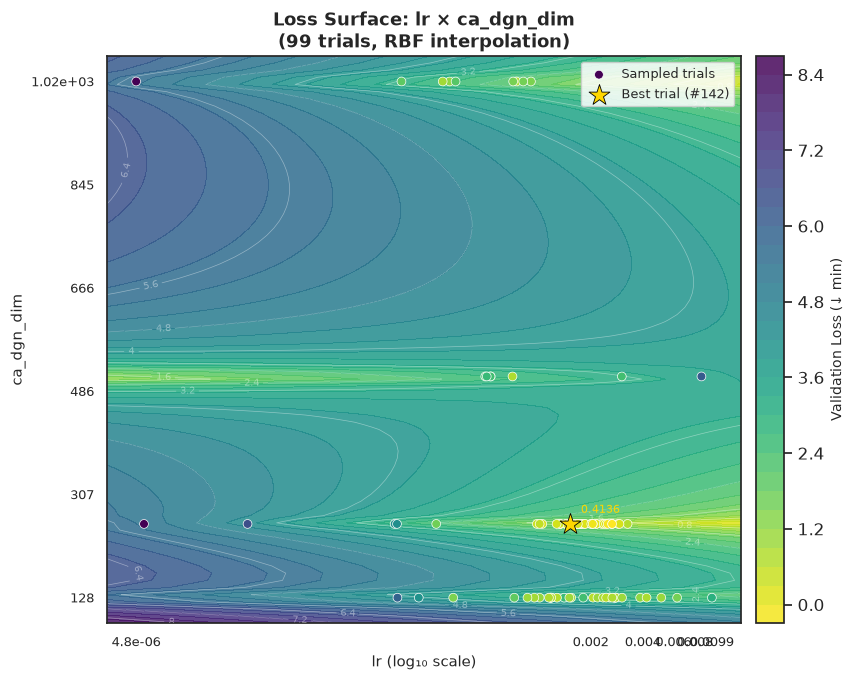

Saved to graphs_and_tables/s1_optuna/0-lr_1-max_layers.png


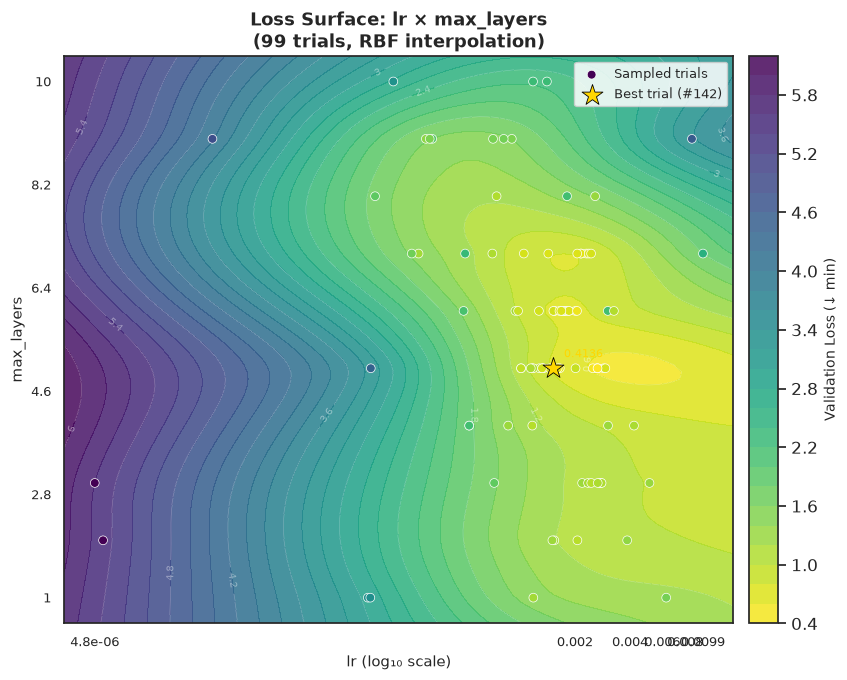

Saved to graphs_and_tables/s1_optuna/0-lr_2-num_iters.png


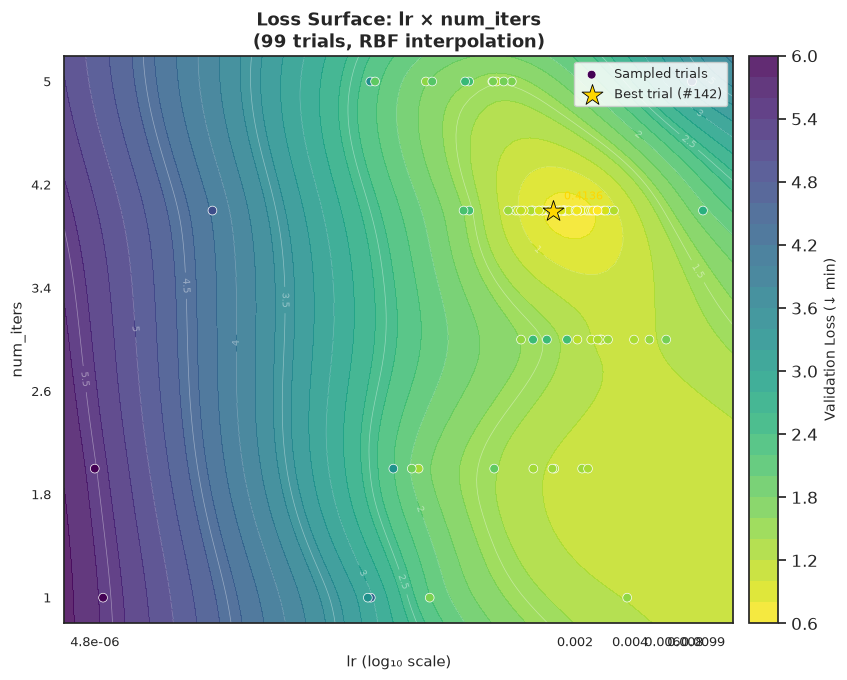

Saved to graphs_and_tables/s1_optuna/0-lr_3-epsilon.png


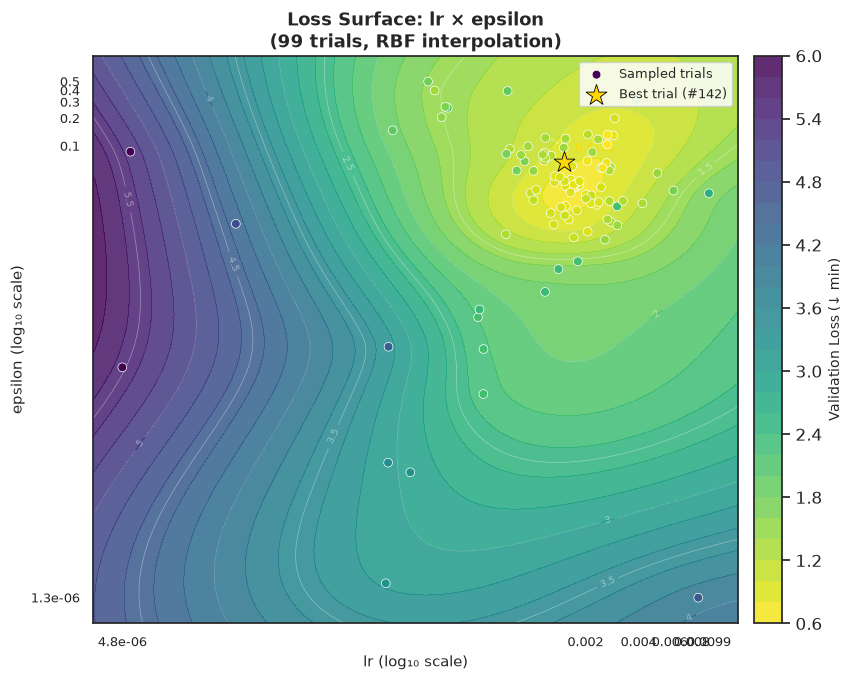

Saved to graphs_and_tables/s1_optuna/0-lr_4-base_gamma.png


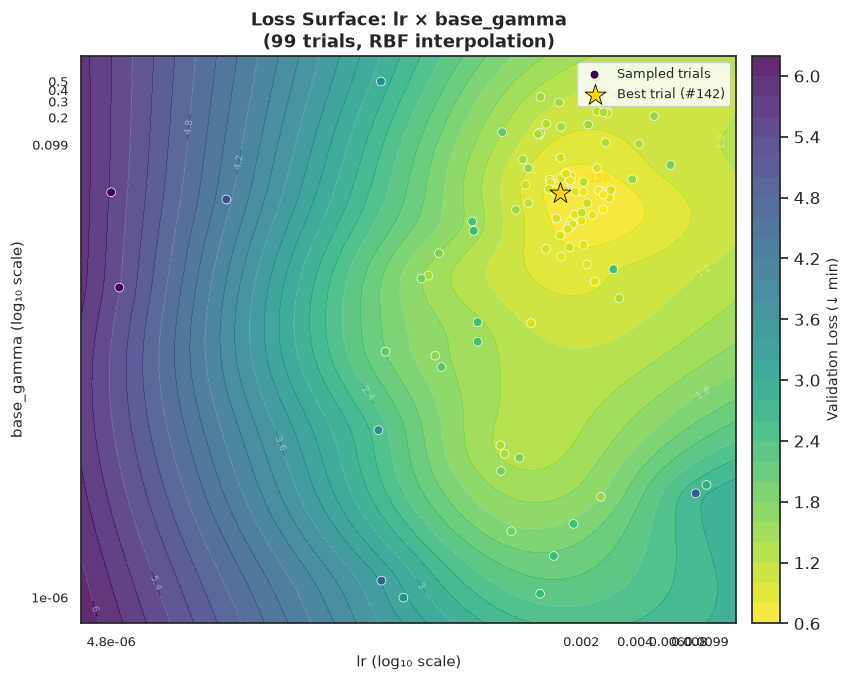

Saved to graphs_and_tables/s1_optuna/0-lr_5-encoder_dropout.png


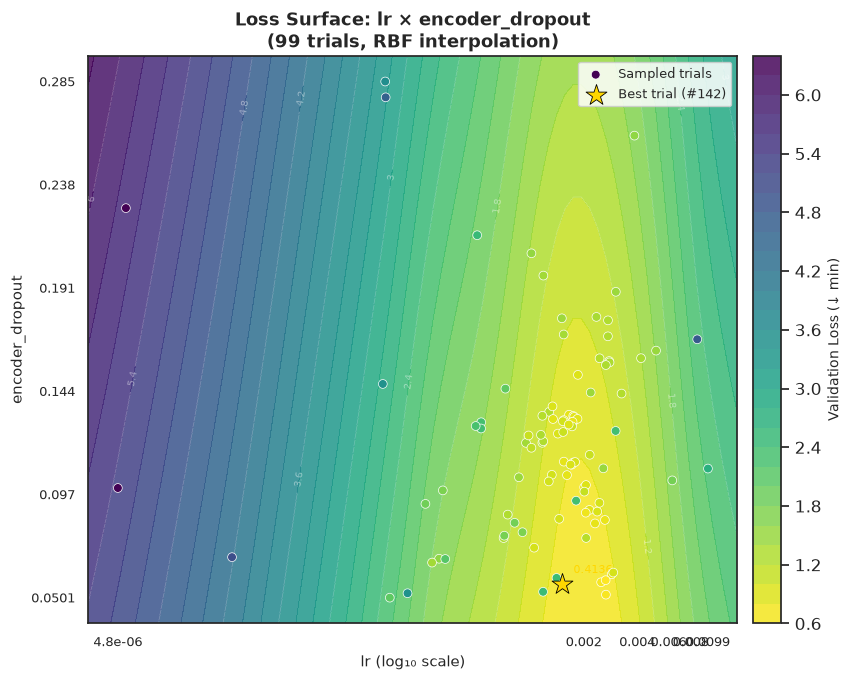

Saved to graphs_and_tables/s1_optuna/0-lr_6-decoder_dropout.png


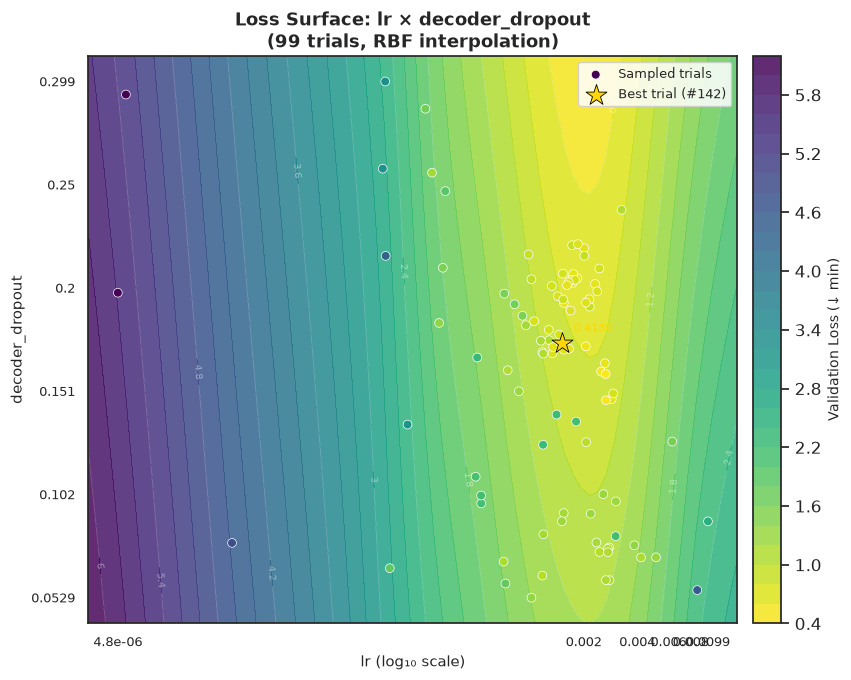

Saved to graphs_and_tables/s1_optuna/0-lr_7-head_encoder_dropout.png


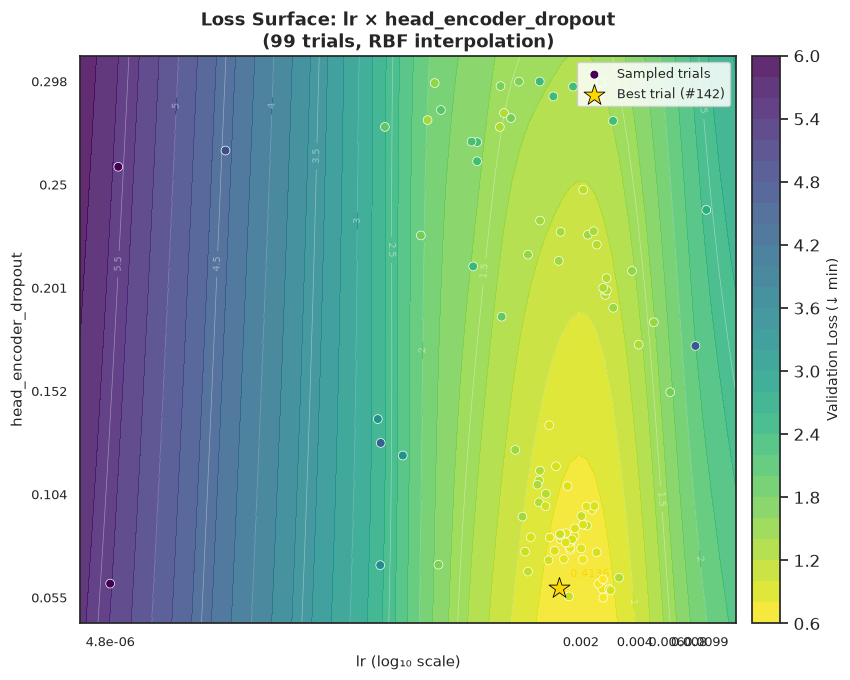

Saved to graphs_and_tables/s1_optuna/0-lr_8-head_decoder_dropout.png


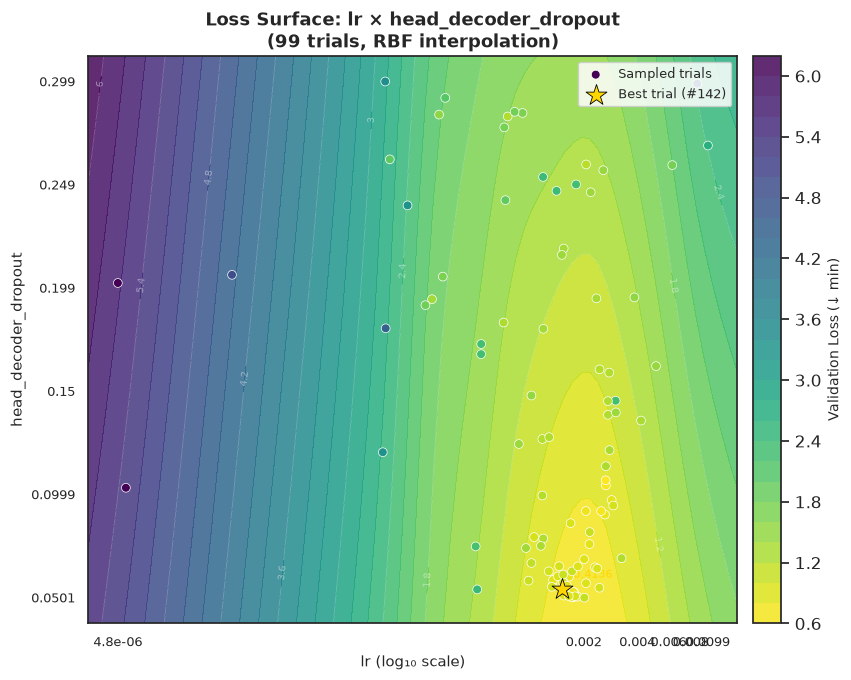

Saved to graphs_and_tables/s1_optuna/0-lr_9-weight_decay.png


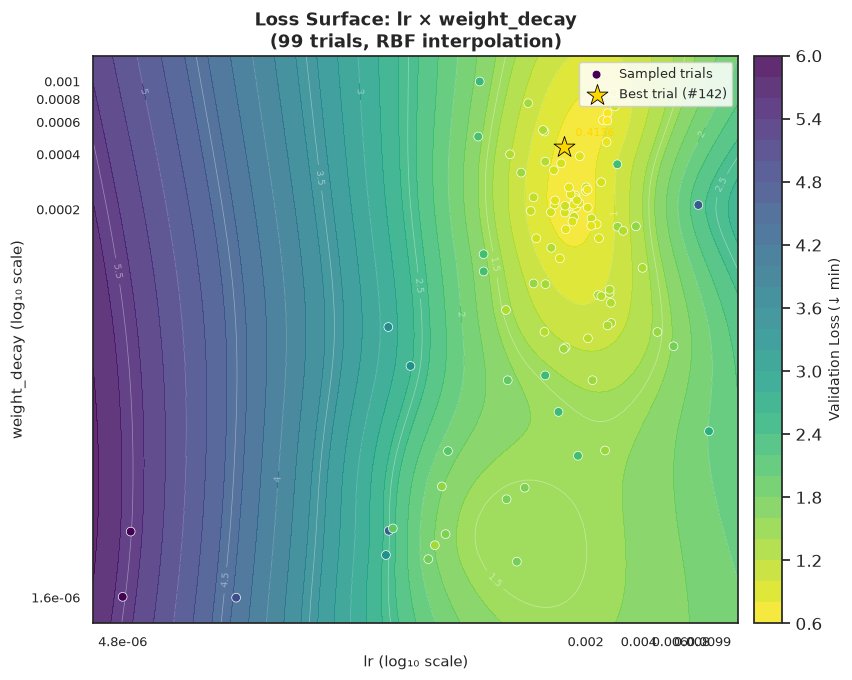

Saved to graphs_and_tables/s1_optuna/0-lr_10-grad_accum_steps.png


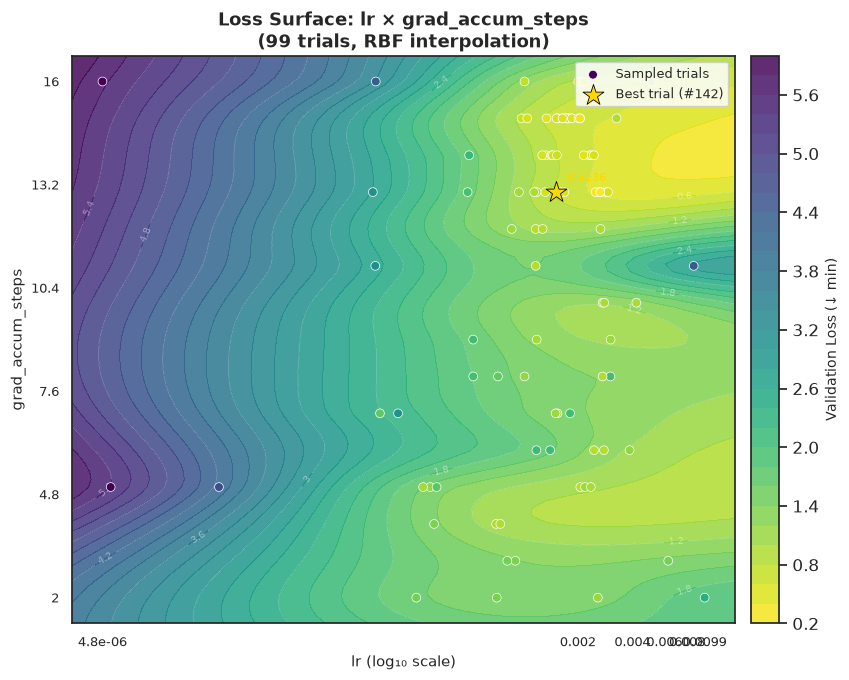

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_1-max_layers.png


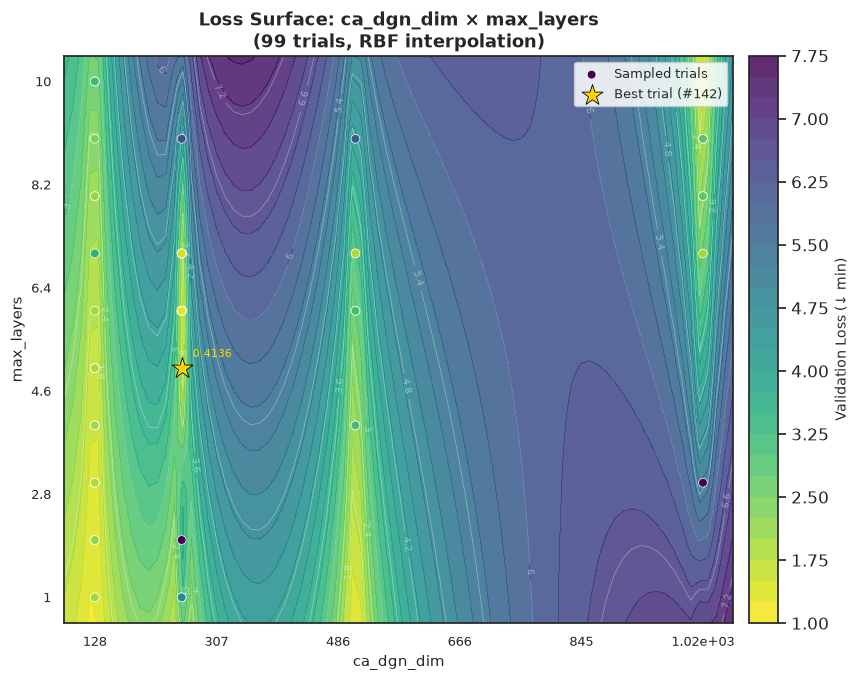

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_2-num_iters.png


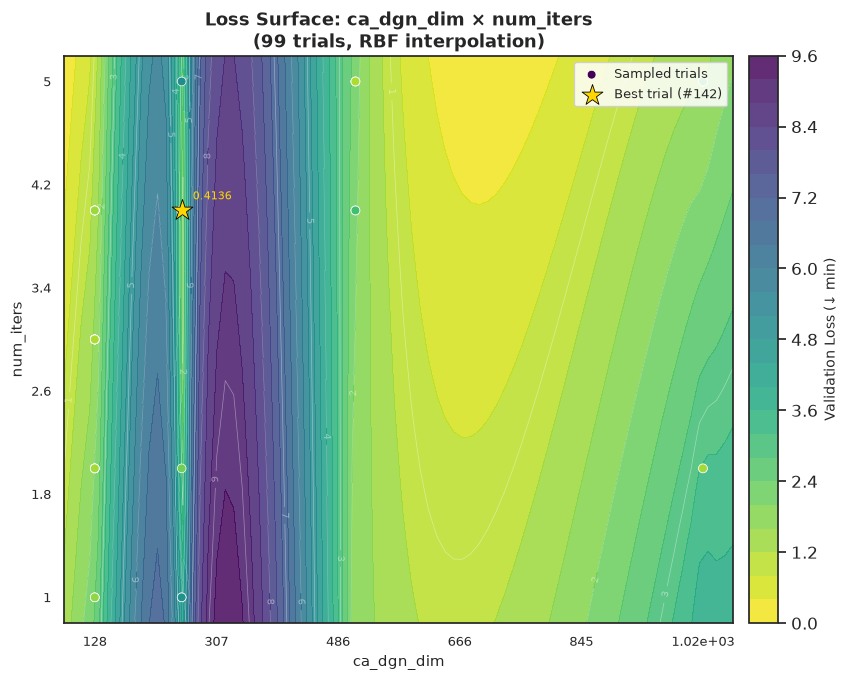

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_3-epsilon.png


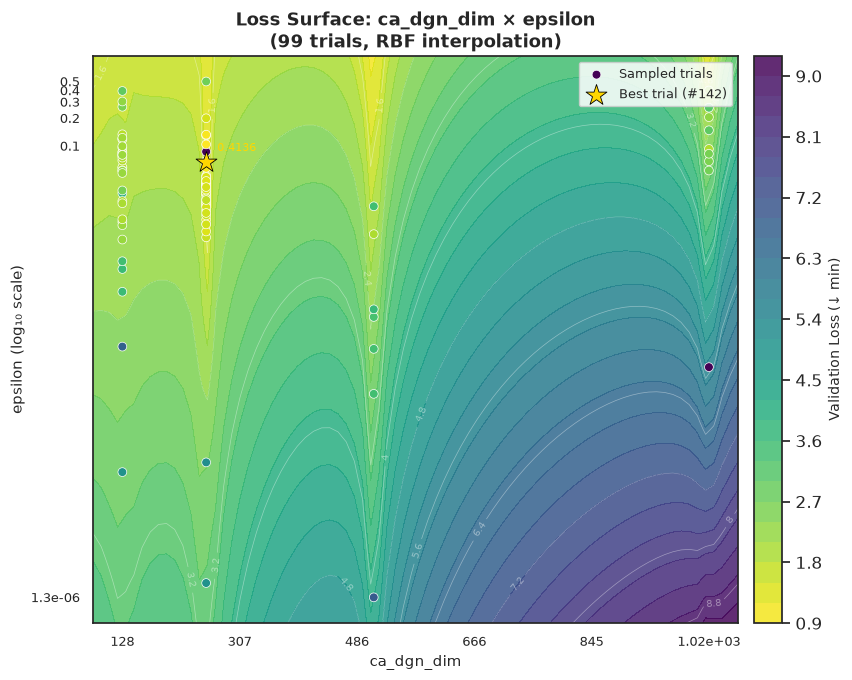

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_4-base_gamma.png


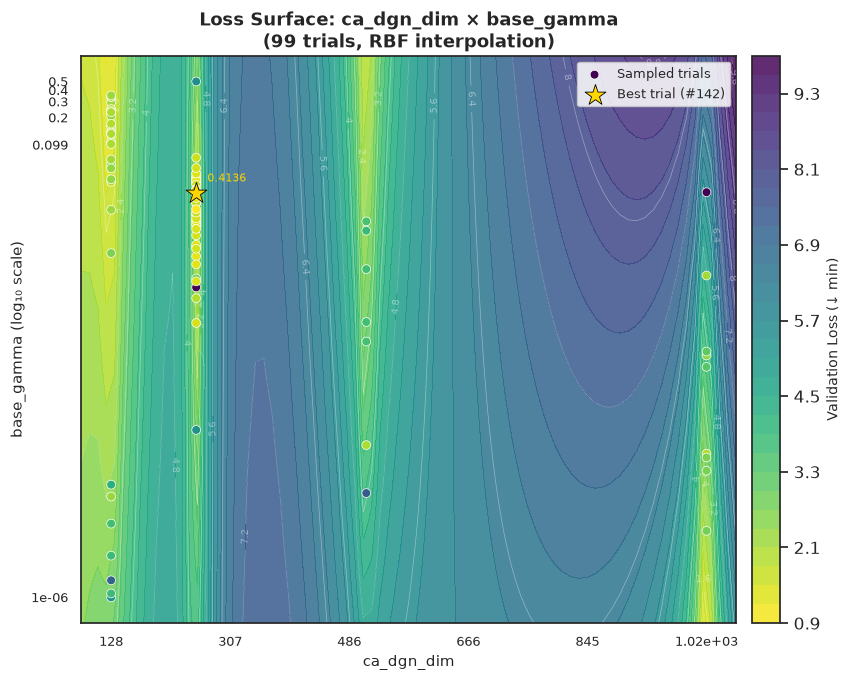

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_5-encoder_dropout.png


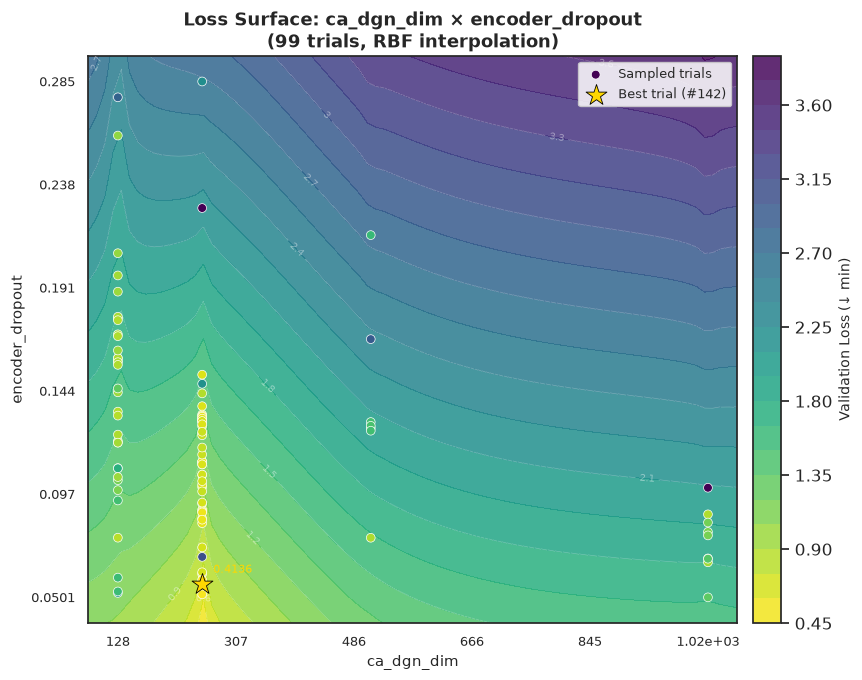

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_6-decoder_dropout.png


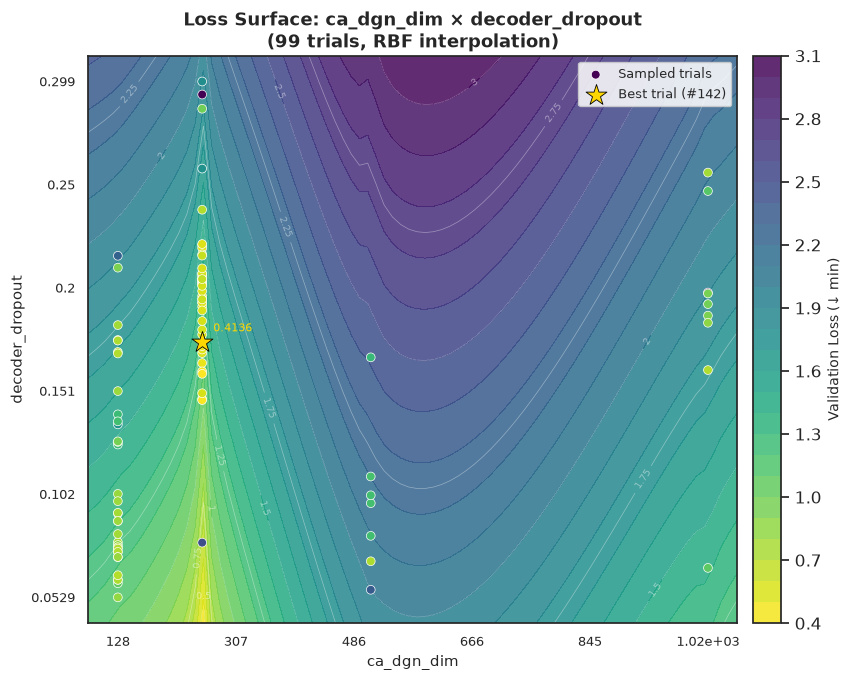

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_7-head_encoder_dropout.png


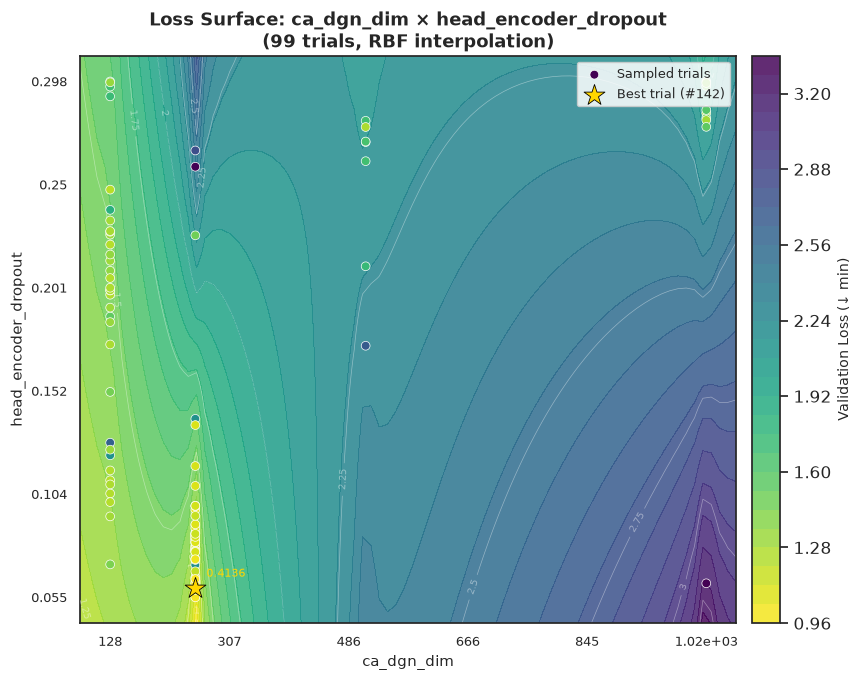

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_8-head_decoder_dropout.png


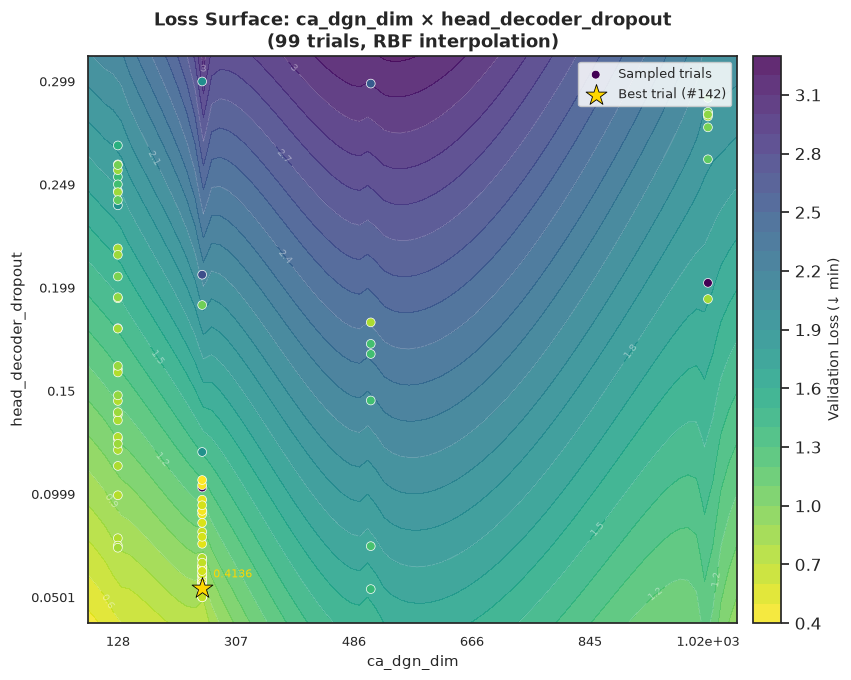

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_9-weight_decay.png


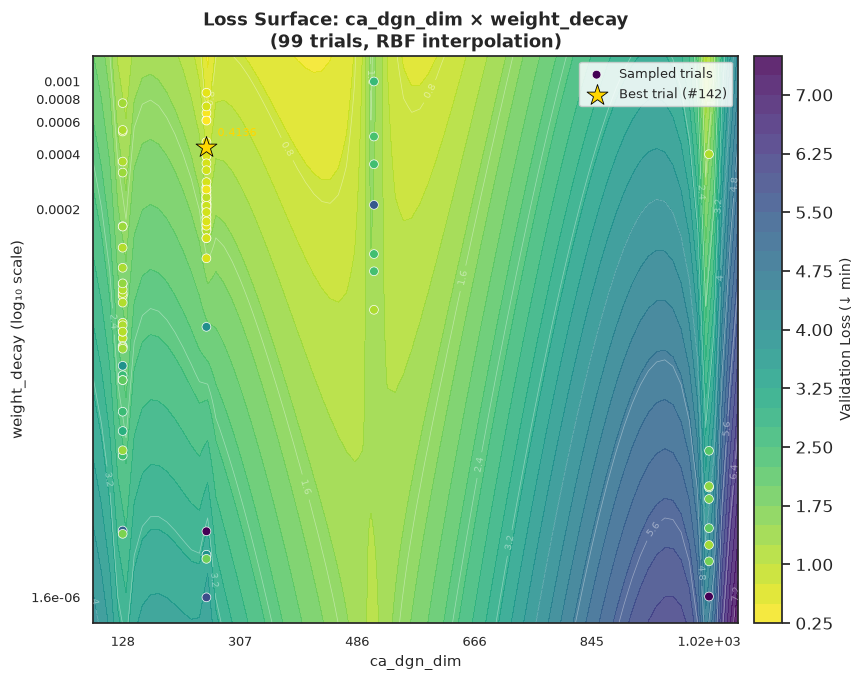

Saved to graphs_and_tables/s1_optuna/1-ca_dgn_dim_10-grad_accum_steps.png


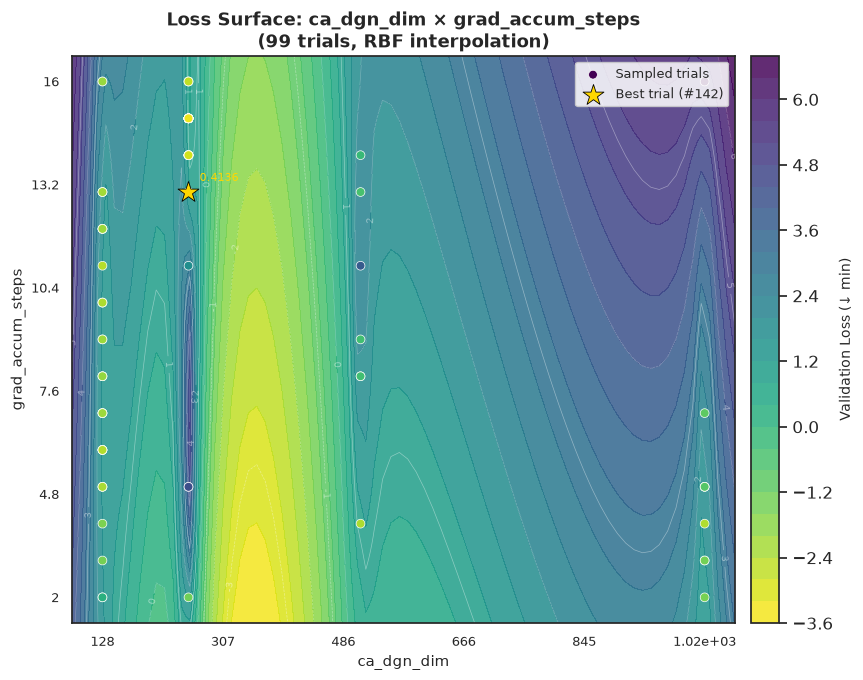

In [32]:
from pathlib import Path
args = [
    ("ca_dgn_dim", False),
    ("max_layers", False),
    ("num_iters", False),
    ("epsilon", True),
    ("base_gamma", True),
    ("encoder_dropout", False),
    ("decoder_dropout", False),
    ("head_encoder_dropout", False),
    ("head_decoder_dropout", False),
    ("weight_decay", True),
    ("grad_accum_steps", False)
]

xaxis = [
    ("lr", True),
    ("ca_dgn_dim", False),
]

rpath = Path("./graphs_and_tables/s1_optuna/")
rpath.mkdir(parents=True, exist_ok=True)

for xi, (xn, x_log) in enumerate(xaxis):
    for yi, (yn, y_log) in enumerate(args):
        if xn == yn:
            continue
        plot_loss_contour(
            study,
            param_x=xn,
            param_y=yn,
            objective_name="Validation Loss",
            log_x=x_log,       # lr is log-distributed in Optuna
            log_y=y_log,
            interpolation="rbf",
            save_path=rpath / f"{xi}-{xn}_{yi}-{yn}.png",
        )
